In [1]:
import pandas as pd
df = pd.read_csv('Refined_TK_dataver2.csv')  # adjust as needed
df['Affiliation'] = df['Affiliation'].fillna('Unknown')
#df = df.replace(to_replace='\n', value=" ", regex=True) #as we are replacing substring, so regex used
df['Affiliation'] = df['Affiliation'].replace({'Gen Mus':'Gen. Musharraf'}) #data munging in column 'Affiliation'
df['Affiliation'] = df['Affiliation'].replace({'Gen Mush':'Gen. Musharraf'})
df['Affiliation'] = df['Affiliation'].replace({'Gen. Musharrafarraf':'Gen. Musharraf'})
df['Detail of Gifts'] = df['Detail of Gifts'].replace({'One Carpet':'One carpet'})

In [2]:
df.sample(5)

,Detail of Gifts,Item Category,Name of Recipient,Affiliation,Date,Assessed Value,Retention Cost,Retained,Remarks
3264,One W/Watch (Ebel)\nModel No.1911BTR\nAutom...,Watch,"Mr. Adeel Ahmed Khan,\nDirector M/o Foreign\...",Unknown,2/17/2016,230000.0,44000.0,Yes,Yes
3352,One W/Watch\n(Tissot)(T41.1.483.33),Watch,"Admiral Muhammad\nZakaullah, Chief of\nNava...",Unknown,8/23/2016,54000.0,0.0,No,No
3708,One state council coin,NaN,Chairman Senate,Unknown,1/29/2019,5000.0,0.0,Yes,Yes
1568,One decoration plate,Decoration Pieces,"Gen Parvez Musharaf,\nPresident of Pakistan",Unknown,6/9/2006,2000.0,0.0,Yes,Yes
3071,(a)One Model of\nBoat.,NaN,"Mr. Muhammad\nNawaz Sharif, Prime\nMinister...",PMLN,1/12/2015,66000.0,0.0,Gifts displayed\nat PM House,Gifts displayed\nat PM House


In [3]:
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:,.0f}'.format
# Convert values to numeric and clean
df['Assessed Value'] = pd.to_numeric(df['Assessed Value'], errors='coerce')
df['Retention Cost'] = pd.to_numeric(df['Retention Cost'], errors='coerce')
# Drop rows where both are missing
df.dropna(subset=['Assessed Value', 'Retention Cost'], how='all', inplace=True)
# Summary stats
print(df[['Assessed Value', 'Retention Cost']].describe())


       Assessed Value  Retention Cost
count           4,213           4,205
mean          321,053          48,513
std         3,894,070         618,454
min                 0               0
25%             1,700               0
50%             8,000               0
75%            40,000           2,250
max       140,000,000      20,178,000


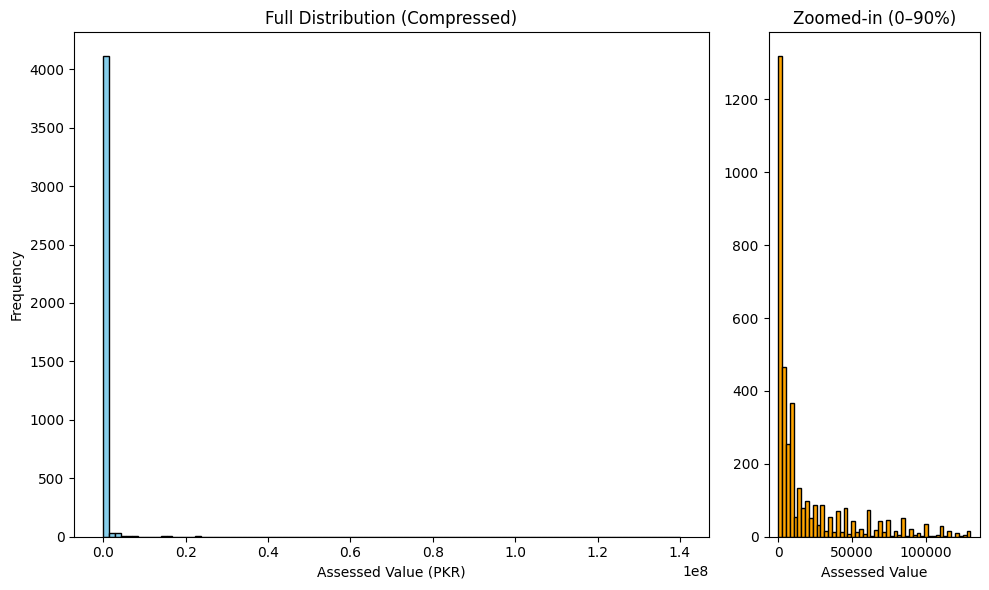

In [4]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Set up main + inset axes
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])
ax_main = plt.subplot(gs[0])
ax_inset = plt.subplot(gs[1])

# Main histogram (full data, compressed view)
ax_main.hist(df['Assessed Value'].dropna(), bins=100, color='skyblue', edgecolor='black')
ax_main.set_title("Full Distribution (Compressed)")
ax_main.set_xlabel("Assessed Value (PKR)")
ax_main.set_ylabel("Frequency")

# Inset histogram (only 0–99th percentile)
assessed_99 = df['Assessed Value'].quantile(0.90)
filtered = df[df['Assessed Value'] <= assessed_99]
ax_inset.hist(filtered['Assessed Value'], bins=50, color='orange', edgecolor='black')
ax_inset.set_title("Zoomed-in (0–90%)")
ax_inset.set_xlabel("Assessed Value")

plt.tight_layout()
plt.show()


<Axes: xlabel='Item Category'>

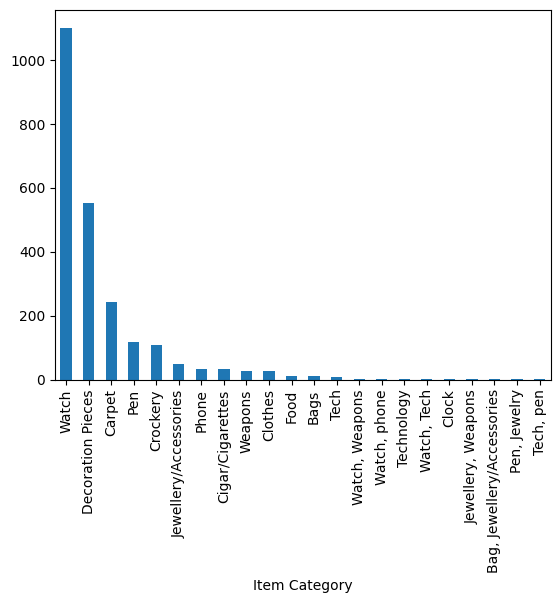

In [5]:
df['Item Category'].value_counts().plot(kind = 'bar')

<Axes: xlabel='Affiliation'>

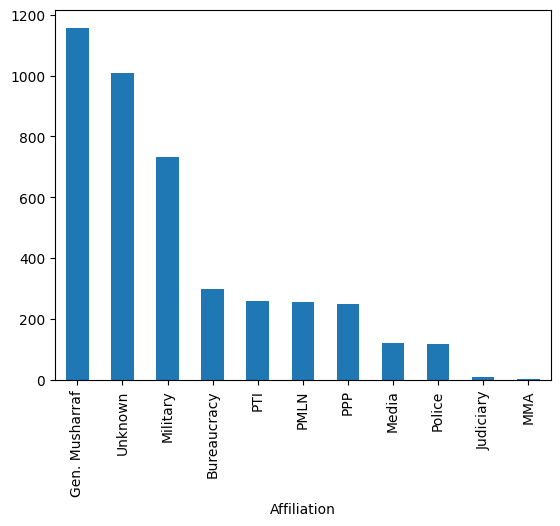

In [6]:
df['Affiliation'].value_counts().plot(kind = 'bar')

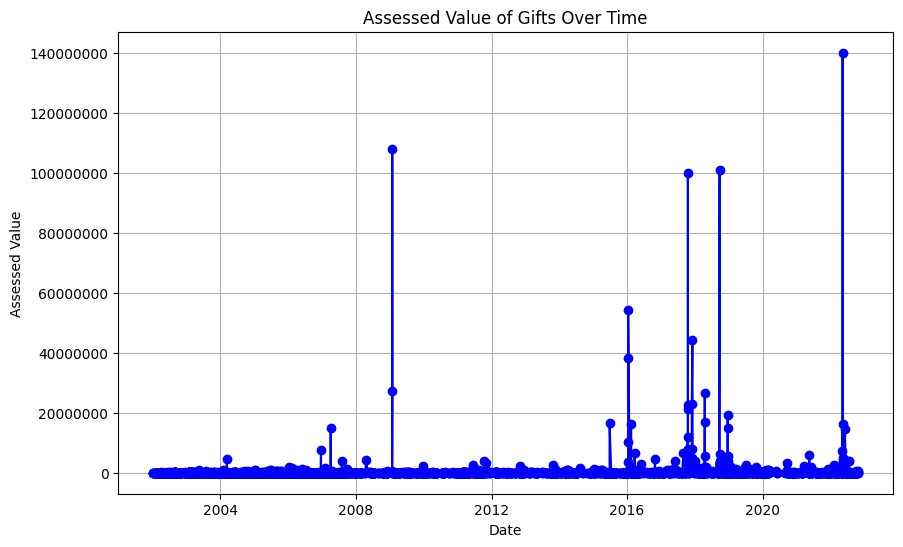

In [7]:
# 1. Convert to datetime (ignore bad formats)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 2. Remove rows with invalid or missing dates or values
df = df.dropna(subset=['Date', 'Assessed Value'])

# 3. Sort by Date
df = df.sort_values('Date')

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Assessed Value'], marker='o', linestyle='-', color='b')
plt.ticklabel_format(style='plain' , axis = 'y')
plt.title('Assessed Value of Gifts Over Time')
plt.xlabel('Date')
plt.ylabel('Assessed Value')
plt.grid(True)
plt.show()

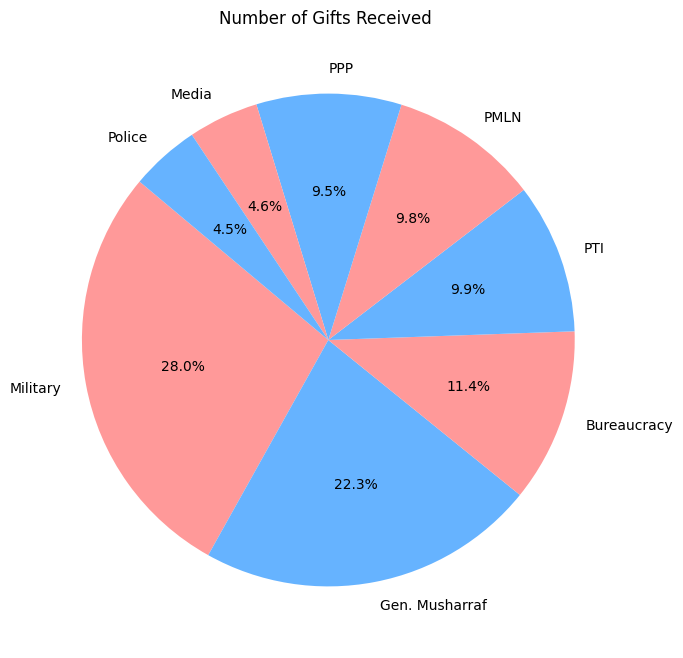

In [5]:
filtered_df = df[df['Affiliation'].isin(['PTI', 'PMLN' ,'PPP' ,'Bureaucracy' , 'Media' ,'Police' ,'Military' ,'Gen. Musharraf'])]

# Count the number of gifts received by each affiliation
affiliation_counts = filtered_df['Affiliation'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(affiliation_counts, labels=affiliation_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Number of Gifts Received ')
plt.show()

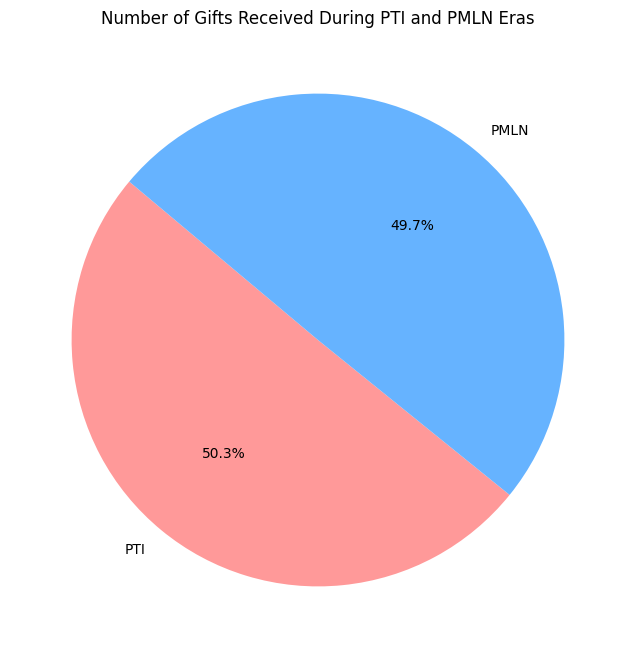

In [9]:
filtered_df = df[df['Affiliation'].isin(['PTI', 'PMLN'])]

# Count the number of gifts received by each affiliation
affiliation_counts = filtered_df['Affiliation'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(affiliation_counts, labels=affiliation_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Number of Gifts Received During PTI and PMLN Eras')
plt.show()

In [10]:
retained_prob = df['Retained'].value_counts(normalize=True).get('Yes', 0)
print(f"Probability of a gift being retained: {retained_prob:.2f}")

Probability of a gift being retained: 0.89


In [11]:
pd.set_option('display.float_format', '{:.4f}'.format)  # show 4 decimal places
affiliation_group = df.groupby('Affiliation')['Retained'].value_counts(normalize=True).unstack()
print("Conditional Probability of Not Retention by Affiliation:")
print(affiliation_group['No'].dropna().sort_values(ascending=False))

Conditional Probability of Not Retention by Affiliation:
Affiliation
PTI           0.2412
PMLN          0.0703
Unknown       0.0647
Bureaucracy   0.0470
Police        0.0336
Military      0.0218
PPP           0.0161
Name: No, dtype: float64


In [12]:
category_group = df.groupby('Item Category')['Retained'].value_counts(normalize=True).unstack()
posterior = category_group['No'].dropna()
print("Posterior probabilities (P(Retained=Not | Item Category)):")
print(posterior.sort_values(ascending=False))

Posterior probabilities (P(Retained=Not | Item Category)):
Item Category
Weapons             0.1481
Crockery            0.1215
Phone               0.0588
Watch               0.0508
Carpet              0.0453
Pen                 0.0336
Decoration Pieces   0.0289
Name: No, dtype: float64


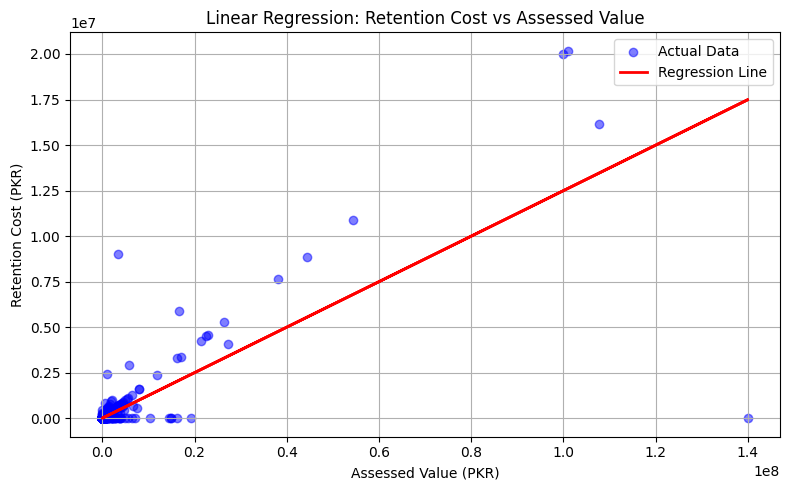

Intercept (β₀): 8450.417218593306
Slope (β₁): 0.12485534591233476
R² Score: 0.6191161231039699


In [4]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Drop rows with missing values in relevant columns
df = df.dropna(subset=['Assessed Value', 'Retention Cost'])
# Reshape data for sklearn
X = df[['Assessed Value']]  # 2D array
y = df['Retention Cost']    # 1D array
# Fit Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Plot actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Linear Regression: Retention Cost vs Assessed Value")
plt.xlabel("Assessed Value (PKR)")
plt.ylabel("Retention Cost (PKR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print model stats
print("Intercept (β₀):", model.intercept_)
print("Slope (β₁):", model.coef_[0])
print("R² Score:", r2_score(y, y_pred))
